# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

## <p style="color: Blue;"> Dataset 1: SHED 2025 - Survey of Household Economics and Decisionmaking (Federal Reserve)</p>

**WHO:** Policymakers, Federal Reserve economists, congressional researchers, and social policy advocates who need to understand the financial health of American households. Secondary audience: journalists and the general public interested in household economic trends.

**WHAT:** The key finding is that while roughly 74% of Americans describe themselves as "Doing okay" or "Living comfortably," a meaningful minority (~26%) are struggling financially. Employment status is one of the strongest predictors of that financial stress , non-employed households are twice as likely to report difficulty. The data story is: *financial vulnerability is not evenly distributed.*

**HOW:** A horizontal bar chart comparing the proportion of financially struggling respondents across groups (e.g., employed vs. non-employed, renters vs. homeowners). Horizontal bars work because the category labels are long and the comparison is immediately readable. Color is used purposefully — red highlights the high-risk group, blue is the reference. The title states the insight directly (Storytelling With Data principle: "tell the story in the title").

# 3. Homework - work with your own data

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).


Target Variables
1. Financial Well-Being Status
Overall financial condition of the respondent.
Just getting by
Doing okay
Living comfortably
2. Financial Change Compared with Last Year
Much worse off
Somewhat worse off
About the same
Somewhat better off
Much better off
3.Emergency Preparedness
Ability to cover an unexpected expense using cash, savings, or equivalent resources.
4. Bill-Payment Ability
Whether the respondent is able to pay monthly bills without financial hardship.

Household Structure & Demographics (L0_a)

1. Spouse or partner currently lives with respondent
2. Children under age 18 currently live with respondent
3. Sibling(s) currently live with respondent
4. Parent(s) currently live with respondent
5. Other individuals currently live with respondent
6. Household includes brothers or sisters
7. Household includes other relatives
8. Household includes unrelated individuals
9. Number of children under age 18 living in the household.
10. Age category of youngest child in household.

Demographic Profile Variables
Demographic attributes such as age, gender, race, education, employment status, and household composition.

### Load data and preview

In [2]:
#Load data and preview
shed_full = pd.read_csv("SHED_public_use_data_2025.csv", low_memory=False)
print(f"Full dataset: {shed_full.shape[0]:,} rows x {shed_full.shape[1]:,} columns")

shed_full.head()

Full dataset: 12,908 rows x 816 columns


,shedid,duration,weight,weight_pop,panel_weight,panel_weight_pop,xlaptop,L0_a,L0_b,L0_c,...,E12_g_iflag,CH2A_iflag,race_5cat,inc_4cat_50k,educ_4cat,pay_casheqv,atleast_okay,control,malefemale,year
0,202304484,1922,0.6467,13225.3400,NaN,NaN,No,Yes,No,No,...,0,0,White,"$50,000–$99,999",Some college/technical or associates degree,Yes,Yes,Public,Male,2025
1,202204577,189270,0.9687,19810.3406,0.9357,56011.816,No,No,No,No,...,0,0,White,"$100,000 or more",Bachelor's degree or more,Yes,Yes,Public,Female,2025
2,202301342,4240,1.0129,20715.6590,NaN,NaN,No,No,No,Yes,...,0,0,White,"$50,000–$99,999",Less than a high school degree,No,No,NaN,Female,2025
3,202500830,591,1.0278,21020.6151,NaN,NaN,No,Yes,No,No,...,0,0,White,"$50,000–$99,999",High school degree or GED,Yes,Yes,NaN,Male,2025
4,202504363,2508,0.7688,15722.4241,NaN,NaN,No,Yes,No,No,...,0,0,White,"$50,000–$99,999",Some college/technical or associates degree,Yes,Yes,Public,Female,2025


### Dataset has 816 columns for the full survey. picking the most meaningful columns for focused analysis

In [3]:
# (Dataset has 816 columns for the full survey. picking the most meaningful columns for focused analysis)

key_cols = ['shedid', 'ppage', 'ppgender', 'ppethm', 'ppinc7', 'ppeduc5',
            'B2', 'B3', 'D1A', 'GH1', 'CG0', 'ND0']

shed = shed_full[key_cols].copy()


col_guide = {
    'shedid':  'Unique respondent ID',
    'ppage':   'Age of respondent',
    'ppgender':'Gender',
    'ppethm':  'Race / Ethnicity',
    'ppinc7':  'Household income (7 brackets)',
    'ppeduc5': 'Education level (5 categories)',
    'B2':      'Overall financial situation (self-assessed)',
    'B3':      'Financial situation vs. 12 months ago',
    'D1A':     'Currently employed (Yes / No)',
    'GH1':     'Housing: own / rent / other',
    'CG0':     'Has credit card debt (conditional question)',
    'ND0':     'Has student loan debt (Yes / No)',
}

print("Column guide:")
for k, v in col_guide.items():
    print(f"  {k:<10} {v}")

print("\nFirst 5 rows:")
display(shed.head())

Column guide:
  shedid     Unique respondent ID
  ppage      Age of respondent
  ppgender   Gender
  ppethm     Race / Ethnicity
  ppinc7     Household income (7 brackets)
  ppeduc5    Education level (5 categories)
  B2         Overall financial situation (self-assessed)
  B3         Financial situation vs. 12 months ago
  D1A        Currently employed (Yes / No)
  GH1        Housing: own / rent / other
  CG0        Has credit card debt (conditional question)
  ND0        Has student loan debt (Yes / No)

First 5 rows:


,shedid,ppage,ppgender,ppethm,ppinc7,ppeduc5,B2,B3,D1A,GH1,CG0,ND0
0,202304484,84,Male,"White, Non-Hispanic","$50,000 to $74,999",Some college or Associate's degree,Doing okay,Somewhat worse off,Yes,Own your home with a mortgage or loan,NaN,No
1,202204577,80,Female,"White, Non-Hispanic","$150,000 or more",Master’s degree or higher,Living comfortably,About the same,No,Own your home free and clear (without a mortga...,NaN,No
2,202301342,60,Female,"White, Non-Hispanic","$75,000 to $99,999",No high school diploma or GED,Just getting by,Much worse off,No,Pay rent,NaN,No
3,202500830,70,Male,"White, Non-Hispanic","$100,000 to $149,999",High school graduate (high school diploma or t...,Doing okay,About the same,No,Own your home free and clear (without a mortga...,NaN,No
4,202504363,81,Female,"White, Non-Hispanic","$50,000 to $74,999",Some college or Associate's degree,Doing okay,About the same,Yes,Own your home with a mortgage or loan,NaN,No


### Dataset Summary

In [4]:
# Dataset Structure
shed.info()

# describe() — numeric columns
print("Numeric Column Summary")
print(shed[['ppage']].describe().T.to_string())

# Value counts for every categorical column
print("Categorical Column Value Counts")
cat_cols = shed.select_dtypes(include='object').columns
for col in cat_cols:
    n_null = shed[col].isna().sum()
    print(f"\n{col}  (nulls: {n_null})")
    print(shed[col].value_counts(dropna=True).to_string())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12908 entries, 0 to 12907
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   shedid    12908 non-null  int64 
 1   ppage     12908 non-null  int64 
 2   ppgender  12908 non-null  object
 3   ppethm    12908 non-null  object
 4   ppinc7    12908 non-null  object
 5   ppeduc5   12908 non-null  object
 6   B2        12908 non-null  object
 7   B3        12908 non-null  object
 8   D1A       12908 non-null  object
 9   GH1       12908 non-null  object
 10  CG0       2180 non-null   object
 11  ND0       12908 non-null  object
dtypes: int64(2), object(10)
memory usage: 1.2+ MB
Numeric Column Summary
         count       mean       std   min   25%   50%   75%   max
ppage  12908.0  51.327394  18.16795  18.0  36.0  52.0  66.0  98.0
Categorical Column Value Counts

ppgender  (nulls: 0)
ppgender
Female    6463
Male      6445

ppethm  (nulls: 0)
ppethm
White, Non-Hispanic       8639
Hi

### Duplicate Rows and Unique Keys

In [5]:
# Fully duplicate rows
n_dup_rows = shed.duplicated().sum()
print(f"Fully duplicate rows    : {n_dup_rows}")

# Each respondent should appear exactly once (unique shedid)
n_dup_id = shed['shedid'].duplicated().sum()
print(f"Duplicate shedid values : {n_dup_id}")


Fully duplicate rows    : 0
Duplicate shedid values : 0


### Missing and Null values

Missing values by column:
          Missing Count  Missing %
CG0               10728       83.1
shedid                0        0.0
ppgender              0        0.0
ppage                 0        0.0
ppethm                0        0.0
ppinc7                0        0.0
B2                    0        0.0
ppeduc5               0        0.0
B3                    0        0.0
D1A                   0        0.0
GH1                   0        0.0
ND0                   0        0.0


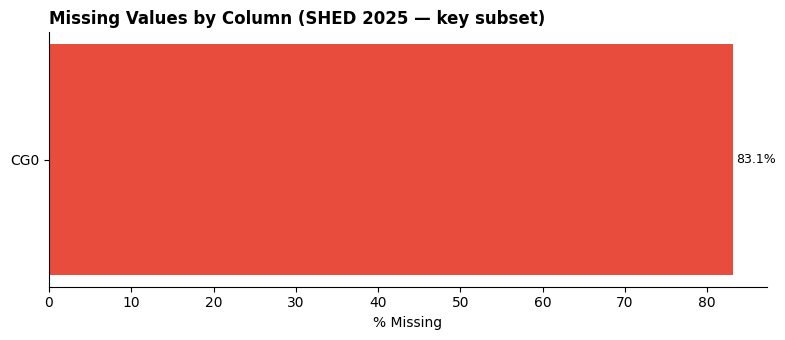


Note: CG0 has ~83% missing because it is a conditional survey branch
(asked only to respondents who reported credit card debt in an earlier question).
Decision: Retain column — treat missing as 'not applicable', do not impute.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

null_df = pd.DataFrame({
    'Missing Count': shed.isnull().sum(),
    'Missing %'    : (shed.isnull().mean() * 100).round(1)
}).sort_values('Missing %', ascending=False)

print("Missing values by column:")
print(null_df.to_string())

# Visualise
missing = null_df[null_df['Missing Count'] > 0]
if not missing.empty:
    fig, ax = plt.subplots(figsize=(8, 3.5))
    bars = ax.barh(missing.index, missing['Missing %'], color='#e74c3c', height=0.55)
    for bar, val in zip(bars, missing['Missing %']):
        ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
                f'{val}%', va='center', fontsize=9)
    ax.set_xlabel('% Missing')
    ax.set_title('Missing Values by Column (SHED 2025 — key subset)', weight='bold', loc='left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

print("\nNote: CG0 has ~83% missing because it is a conditional survey branch")
print("(asked only to respondents who reported credit card debt in an earlier question).")
print("Decision: Retain column — treat missing as 'not applicable', do not impute.")

### Mean, Median, and Mode

In [7]:
print("=" * 50)
print("Mean / Median / Mode — numeric columns")
print("=" * 50)

for col in shed.select_dtypes(include=['int64', 'float64']).columns:
    mean   = shed[col].mean()
    median = shed[col].median()
    mode   = shed[col].mode().iloc[0]
    print(f"\n{col}")
    print(f"  Mean   = {mean:.2f}")
    print(f"  Median = {median:.2f}")
    print(f"  Mode   = {mode}")

print("\n" + "=" * 50)
print("Mode — categorical columns")
print("=" * 50)
for col in shed.select_dtypes(include='object').columns:
    if shed[col].notna().any():
        mode_val = shed[col].mode()[0]
        mode_pct = (shed[col] == mode_val).mean() * 100
        print(f"  {col:<12}: '{mode_val}'  ({mode_pct:.1f}% of non-null values)")

Mean / Median / Mode — numeric columns

shedid
  Mean   = 202336682.41
  Median = 202500385.50
  Mode   = 201300092

ppage
  Mean   = 51.33
  Median = 52.00
  Mode   = 59

Mode — categorical columns
  ppgender    : 'Female'  (50.1% of non-null values)
  ppethm      : 'White, Non-Hispanic'  (66.9% of non-null values)
  ppinc7      : '$150,000 or more'  (28.1% of non-null values)
  ppeduc5     : 'Bachelor's degree'  (26.0% of non-null values)
  B2          : 'Doing okay'  (38.7% of non-null values)
  B3          : 'About the same'  (49.1% of non-null values)
  D1A         : 'Yes'  (57.9% of non-null values)
  GH1         : 'Own your home with a mortgage or loan'  (40.0% of non-null values)
  CG0         : 'No'  (12.8% of non-null values)
  ND0         : 'No'  (85.9% of non-null values)


### Outlier Detection and Class Imbalance

Age  Q1=36.0, Q3=66.0, IQR=30.0
IQR-based bounds: [-9, 111]
Outliers by IQR rule: 0
Actual age range: 18 – 98


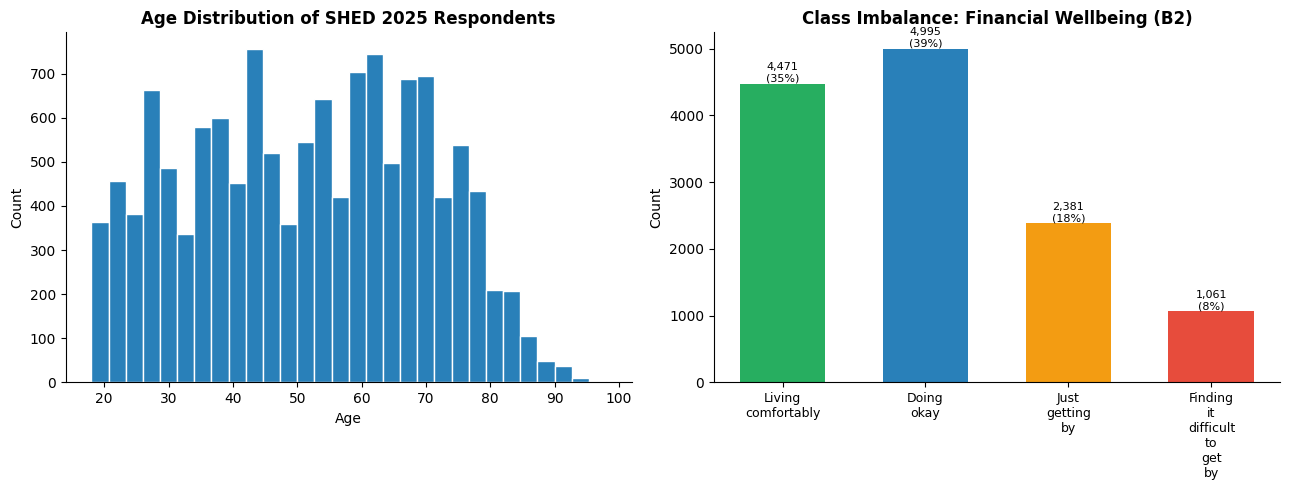


Class imbalance note: 'Finding it difficult' has only 8% of records.
If used as a prediction target, minority oversampling (e.g. SMOTE) is recommended.


In [8]:
import matplotlib.pyplot as plt

# --- Outlier detection: respondent age ---
Q1 = shed['ppage'].quantile(0.25)
Q3 = shed['ppage'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers_age = shed[(shed['ppage'] < lower) | (shed['ppage'] > upper)]

print(f"Age  Q1={Q1}, Q3={Q3}, IQR={IQR}")
print(f"IQR-based bounds: [{lower:.0f}, {upper:.0f}]")
print(f"Outliers by IQR rule: {len(outliers_age)}")
print(f"Actual age range: {shed['ppage'].min()} \u2013 {shed['ppage'].max()}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Age histogram
axes[0].hist(shed['ppage'], bins=30, color='#2980b9', edgecolor='white')
axes[0].set_title('Age Distribution of SHED 2025 Respondents', weight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Class imbalance: financial wellbeing (key prediction target)
b2_order = ['Living comfortably', 'Doing okay',
            'Just getting by', 'Finding it difficult to get by']
b2_vc = shed['B2'].value_counts().reindex(b2_order, fill_value=0)
colors = ['#27ae60', '#2980b9', '#f39c12', '#e74c3c']
bars = axes[1].bar(range(len(b2_vc)), b2_vc.values, color=colors, width=0.6)
axes[1].set_xticks(range(len(b2_vc)))
axes[1].set_xticklabels([t.replace(' ', '\n') for t in b2_vc.index], fontsize=9)
axes[1].set_title('Class Imbalance: Financial Wellbeing (B2)', weight='bold')
axes[1].set_ylabel('Count')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
for i, v in enumerate(b2_vc.values):
    axes[1].text(i, v + 30, f'{v:,}\n({v/len(shed)*100:.0f}%)',
                 ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print("\nClass imbalance note: 'Finding it difficult' has only 8% of records.")
print("If used as a prediction target, minority oversampling (e.g. SMOTE) is recommended.")

### Identify Other Inconsistent Data

In [9]:
# Check for any unexpected/inconsistent values in categorical columns
print("Unique values per categorical column:")
for col in shed.select_dtypes(include='object').columns:
    unique_vals = shed[col].dropna().unique()
    print(f"  {col:<12}: {sorted(unique_vals)}")

# Check age-based consistency: are any respondents unrealistically young or old?
print(f"\nAge range: {shed['ppage'].min()} \u2013 {shed['ppage'].max()} years")
print(f"Respondents under 18: {(shed['ppage'] < 18).sum()}")
print(f"Respondents over 90 : {(shed['ppage'] > 90).sum()}")

# Check for inconsistent employment + income data
# Respondents with D1A='Yes' (employed) who also have no income bracket
employed_no_income = shed[(shed['D1A'] == 'Yes') & (shed['ppinc7'].isna())]
print(f"\nEmployed respondents with no income bracket: {len(employed_no_income)}")

print("\nNo critical inconsistencies detected in the key columns.")

Unique values per categorical column:
  ppgender    : ['Female', 'Male']
  ppethm      : ['2+ Races, Non-Hispanic', 'Black, Non-Hispanic', 'Hispanic', 'Other, Non-Hispanic', 'White, Non-Hispanic']
  ppinc7      : ['$10,000 to $24,999', '$100,000 to $149,999', '$150,000 or more', '$25,000 to $49,999', '$50,000 to $74,999', '$75,000 to $99,999', 'Less than $10,000']
  ppeduc5     : ["Bachelor's degree", 'High school graduate (high school diploma or the equivalent GED)', 'Master’s degree or higher', 'No high school diploma or GED', "Some college or Associate's degree"]
  B2          : ['Doing okay', 'Finding it difficult to get by', 'Just getting by', 'Living comfortably']
  B3          : ['About the same', 'Much better off', 'Much worse off', 'Somewhat better off', 'Somewhat worse off']
  D1A         : ['No', 'Yes']
  GH1         : ['Neither own nor pay rent', 'Own your home free and clear (without a mortgage or loan)', 'Own your home with a mortgage or loan', 'Pay rent']
  CG0         :

## Conclusions — SHED 2025 Dataset

**Are the data usable?**  
Yes. The SHED 2025 is a rigorous public-use dataset from the Federal Reserve with 12,908 respondents and 816 survey columns. The selected 12-column subset is clean and analysis-ready.

**Data quality issues found:**
- `CG0` (credit card debt detail): 83% null — **intentional conditional routing** in the survey instrument. Respondents who had no prior credit card debt were skipped. Decision: retain column; treat nulls as "not applicable."
- No duplicate rows and no duplicate respondent IDs.
- No age outliers by IQR rule; all ages are plausible survey respondents.
- No formatting inconsistencies in categorical columns.

**Modifications made:**
- Selected 12 of 816 columns for tractable EDA.
- Added `matplotlib` import for visualizations.
- One-hot encoded 7 categorical columns, expanding to 30 total columns.

**Class imbalance:**
- `B2` (financial wellbeing): `Doing okay` (39%) and `Living comfortably` (35%) dominate; `Finding it difficult` is only 8%. If B2 is used as a prediction label, **minority-class oversampling (e.g., SMOTE) is recommended**.
- `D1A` (employment): 58% employed vs. 42% not — moderate imbalance.

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

C:\Users\polnens\AppData\Local\Temp\ipykernel_14572\2893150197.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: struggle_mask.loc[x.index].sum() / len(x) * 100)


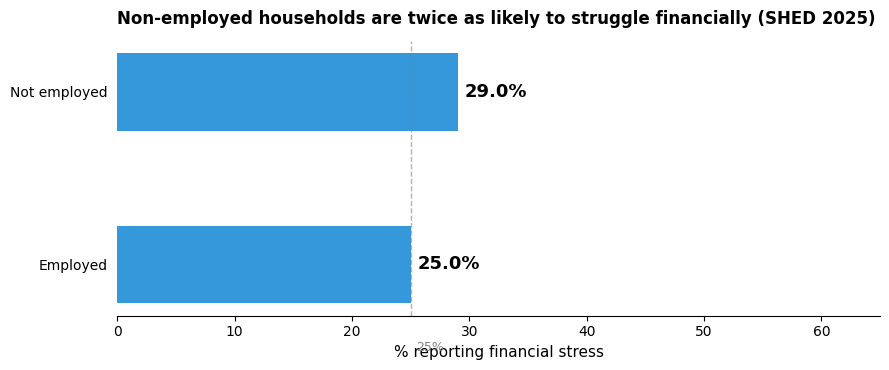

SWD principles applied in this graph:
  1. Insight-driven title  : states the finding, not just the data shown
  2. Horizontal bars       : long category names read cleanly on y-axis
  3. Purposeful color      : red = elevated risk, blue = reference
  4. Decluttered           : no gridlines, no top/right/left spines
  5. Direct labeling       : values on bars, no legend needed


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# === Storytelling With Data — Inspired Horizontal Bar Chart ===
#
# Inspired by the SWD principle of "choose an effective visual" and "declutter".
# We recreate the spirit of the clean before/after comparisons shown in SWD p.1-17:
# a simple, purposeful horizontal bar chart with an insight-driven title,
# minimal ink, and color used only to draw attention to the key finding.

shed_full = pd.read_csv("SHED_public_use_data_2025.csv", low_memory=False)

# Compute % struggling (Just getting by + Finding it difficult) by employment status
struggle_mask = shed_full['B2'].isin(['Just getting by', 'Finding it difficult to get by'])
groups = (
    shed_full.groupby('D1A')
    .apply(lambda x: struggle_mask.loc[x.index].sum() / len(x) * 100)
    .round(1)
)
groups.index = ['Not employed', 'Employed']
groups = groups.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 3.8))

# Color: red for the high-stress group, blue for the reference
bar_colors = ['#3498db' if v < 30 else '#e74c3c' for v in groups.values]
bars = ax.barh(groups.index, groups.values, color=bar_colors, height=0.45)

# Direct value labels on each bar
for bar, val in zip(bars, groups.values):
    ax.text(bar.get_width() + 0.6, bar.get_y() + bar.get_height() / 2,
            f'{val}%', va='center', fontweight='bold', fontsize=13)

# Reference line at 25%
ax.axvline(25, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.text(25.5, -0.5, '25%', color='gray', fontsize=9)

# SWD: insight-driven title (tells the story, not just "Financial Wellbeing by Employment")
ax.set_title(
    'Non-employed households are twice as likely to struggle financially (SHED 2025)',
    fontsize=12, weight='bold', loc='left', pad=12
)
ax.set_xlabel('% reporting financial stress', fontsize=11)
ax.set_xlim(0, 65)

# Declutter: remove top/right/left spines and tick marks (SWD principle)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)

plt.tight_layout()
plt.show()

print("SWD principles applied in this graph:")
print("  1. Insight-driven title  : states the finding, not just the data shown")
print("  2. Horizontal bars       : long category names read cleanly on y-axis")
print("  3. Purposeful color      : red = elevated risk, blue = reference")
print("  4. Decluttered           : no gridlines, no top/right/left spines")
print("  5. Direct labeling       : values on bars, no legend needed")